In [1]:
from abc import ABC, abstractmethod
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
class spacetime(ABC):
    @abstractmethod
    def H(self, x, p):
        pass

    @abstractmethod
    def dHdx(self, x, p):
        pass

    @abstractmethod
    def dHdp(self, x, p):
        pass

class integrator(ABC):
    @abstractmethod
    def step(self, x, p, dt):
        pass

In [3]:
class RungeKutta4(integrator):
    def __init__(self, sptm):
        self.sptm = sptm

    def step(self, x, p, dt):
        # Step 1
        dHp1 = self.sptm.dHdp(x, p)
        dHx1 = self.sptm.dHdx(x, p)
        k1 = -dHx1 * dt
        l1 = dHp1 * dt

        # Step 2
        dHp2 = self.sptm.dHdp(x + 0.5*l1, p + 0.5*k1)
        dHx2 = self.sptm.dHdx(x + 0.5*l1, p + 0.5*k1)
        k2 = -dHx2 * dt
        l2 = dHp2 * dt

        # Step 3
        dHp3 = self.sptm.dHdp(x + 0.5*l2, p + 0.5*k2)
        dHx3 = self.sptm.dHdx(x + 0.5*l2, p + 0.5*k2)
        k3 = -dHx3 * dt
        l3 = dHp3 * dt

        # Step 4
        dHp4 = self.sptm.dHdp(x + l3, p + k3)
        dHx4 = self.sptm.dHdx(x + l3, p + k3)
        k4 = -dHx4 * dt
        l4 = dHp4 * dt

        p_new = p + (k1 + 2*k2 + 2*k3 + k4) / 6.
        x_new = x + (l1 + 2*l2 + 2*l3 + l4) / 6.

        return x_new, p_new

In [4]:
class kerrDeSitter(spacetime):
    def __init__(self, M, a, lmd):
        self.M_val = M
        self.a_val = a
        self.lmd_val = lmd
        self._derive_symbolic_equations()

    def _derive_symbolic_equations(self):
        # 1. Definisi Simbol
        t, r, th, ph = sp.symbols('t r theta phi')
        pt, pr, pth, pph = sp.symbols('pt pr ptheta pphi')
        M, a, L = sp.symbols('M a Lambda')

        # 2. Definisi Fungsi Metrik (Boyer-Lindquist) Kerr-de Sitter
        Sigma = r**2 + (a * sp.cos(th))**2
        Delta_r = (r**2 + a**2) * (1 - (L * r**2)/3) - 2*M*r
        Delta_th = 1 + (L * a**2 * sp.cos(th)**2)/3
        Xi = 1 + (L * a**2)/3

        # Ekstrak komponen metrik kovarian g_uv
        g_tt = - (Delta_r / Sigma) + (Delta_th * sp.sin(th)**2 / Sigma) * a**2
        g_rr = Sigma / Delta_r
        g_thth = Sigma / Delta_th
        g_pp = -(Delta_r/Sigma) * (a * sp.sin(th)**2 / Xi)**2 + \
               (Delta_th * sp.sin(th)**2 / Sigma) * ((r**2 + a**2)/Xi)**2
        g_tp = -(Delta_r/Sigma) * (-a * sp.sin(th)**2 / Xi) + \
               (Delta_th * sp.sin(th)**2 / Sigma) * (-a * (r**2 + a**2)/Xi)

        # Matriks Metrik
        g_mat = sp.Matrix([
            [g_tt, 0, 0, g_tp],
            [0, g_rr, 0, 0],
            [0, 0, g_thth, 0],
            [g_tp, 0, 0, g_pp]
        ])

        # Inverse Metrik g^uv
        g_inv = g_mat.inv()

        # 3. Hamiltonian H = 1/2 g^uv p_u p_v
        p_vec = sp.Matrix([pt, pr, pth, pph])
        # Gunakan simplify untuk hasil yang lebih akurat
        self.Ham_expr = sp.simplify(0.5 * (p_vec.T * g_inv * p_vec)[0])

        # 4. Turunan Hamiltonian
        vars_x = [t, r, th, ph]
        vars_p = [pt, pr, pth, pph]

        dHdx_expr = [sp.diff(self.Ham_expr, v) for v in vars_x]
        dHdp_expr = [sp.diff(self.Ham_expr, v) for v in vars_p]

        # 5. Lambdify
        params = (t, r, th, ph, pt, pr, pth, pph, M, a, L)

        self.f_H = sp.lambdify(params, self.Ham_expr, 'numpy')
        self.f_dHdx = sp.lambdify(params, dHdx_expr, 'numpy')
        self.f_dHdp = sp.lambdify(params, dHdp_expr, 'numpy')
        self.f_g_inv = sp.lambdify(params[:4] + (M, a, L), g_inv, 'numpy') # Untuk initial condition

    def _unpack_state(self, x, p):
        return x[0], x[1], x[2], x[3], p[0], p[1], p[2], p[3]

    def H(self, x, p):
        args = (*self._unpack_state(x, p), self.M_val, self.a_val, self.lmd_val)
        return self.f_H(*args)

    def dHdx(self, x, p):
        args = (*self._unpack_state(x, p), self.M_val, self.a_val, self.lmd_val)
        return np.array(self.f_dHdx(*args))

    def dHdp(self, x, p):
        args = (*self._unpack_state(x, p), self.M_val, self.a_val, self.lmd_val)
        return np.array(self.f_dHdp(*args))

    def get_initial_pr(self, x, E, L_ang):
        t, r, th, ph = x
        args = (t, r, th, ph, self.M_val, self.a_val, self.lmd_val)
        g_inv = self.f_g_inv(*args)

        gUU_tt = g_inv[0,0]
        gUU_rr = g_inv[1,1]
        gUU_thth = g_inv[2,2]
        gUU_pp = g_inv[3,3]
        gUU_tp = g_inv[0,3]

        if abs(gUU_rr) < 1e-10:
            raise ValueError(f"g^rr too small ({gUU_rr}) at r={r}")

        residue = gUU_tt * E**2 + gUU_pp * L_ang**2 + 2 * gUU_tp * (-E) * L_ang
        pr_sq = -residue / gUU_rr

        if pr_sq < 0:
            raise ValueError(f"Forbidden region: pr^2={pr_sq} < 0 at r={r}, with E={E}, L={L_ang}")

        return -np.sqrt(pr_sq)

In [5]:
# Parameter Fisika
M = 1.0
a = -0.99
lambdas = [0.0, -1e-8, -5e-8, -1e-7, -5e-7, -1e-6, -5e-6]

# Kondisi Awal Cahaya
r0 = 500.0
theta0 = np.pi / 2
phi0 = 0.0

# Parameter Cahaya
E = 1.0
b = 7
L_ang = b * E

# List untuk menyimpan data lintas sel
lambda_vals = []
deflection_vals = []
trajectories = [] # Menyimpan data X_vals dan Y_vals untuk plotting di sel terpisah

# Radius Event Horizon untuk visualisasi (Kerr approx)
rh = M + np.sqrt(M**2 - a**2)

In [6]:
print(f"{'a':<10} | {'Lambda':<10} | {'Deflection (deg)':<20} | {'Status'}")
print("-" * 55)

for i, lmd in enumerate(lambdas):
    # Inisialisasi Spacetime
    sptm = kerrDeSitter(M, a, lmd)
    intg = RungeKutta4(sptm)

    # Setup Initial State
    x = np.array([0.0, r0, theta0, phi0])

    try:
        pr_init = sptm.get_initial_pr(x, E, L_ang)
    except ValueError:
        print(f"Skipping L={lmd}: Initial condition invalid")
        continue

    p = np.array([-E, pr_init, 0.0, L_ang])

    # Integrasi
    tau = 0
    dtau = 0.05
    X_vals = []
    Y_vals = []
    Phi_vals = []
    hamiltonian_values = []  # Inisialisasi list untuk Hamiltonian

    steps = 0
    max_steps = 30000

    while steps < max_steps:
        x, p = intg.step(x, p, dtau)

        r_curr = x[1]
        phi_curr = x[3]

        # Simpan nilai Hamiltonian di setiap langkah
        H_val = sptm.H(x, p)
        hamiltonian_values.append(H_val)

        # Konversi ke Cartesian untuk plot (projected)
        X_vals.append(r_curr * np.cos(phi_curr))
        Y_vals.append(r_curr * np.sin(phi_curr))
        Phi_vals.append(phi_curr)

        # Stop Conditions
        if r_curr < rh * 1.1: # Jatuh ke lubang hitam
            break
        if r_curr > r0 + 5 and steps > 10: # Keluar kembali (scattering)
            break

        steps += 1

    # Analisis Defleksi
    phi_in = phi0
    phi_out = Phi_vals[-1]

    # Total perubahan sudut mutlak dikurangi pi
    deflection = abs(abs(phi_out - phi_in) - np.pi)
    def_deg = np.degrees(deflection)

    # Simpan data untuk diakses oleh sel plotting
    lambda_vals.append(lmd)
    deflection_vals.append(def_deg)
    trajectories.append((lmd, X_vals, Y_vals))

    print(f"{a:<10} | {lmd:<10} | {def_deg:<20.4f} | Steps: {steps}")


a          | Lambda     | Deflection (deg)     | Status
-------------------------------------------------------
-0.99      | 0.0        | 244.4703             | Steps: 20374
-0.99      | -1e-08     | 244.4689             | Steps: 20374
-0.99      | -5e-08     | 244.4637             | Steps: 20374
-0.99      | -1e-07     | 244.4571             | Steps: 20374
-0.99      | -5e-07     | 244.4042             | Steps: 20374
-0.99      | -1e-06     | 244.3381             | Steps: 20374
-0.99      | -5e-06     | 243.8062             | Steps: 20374


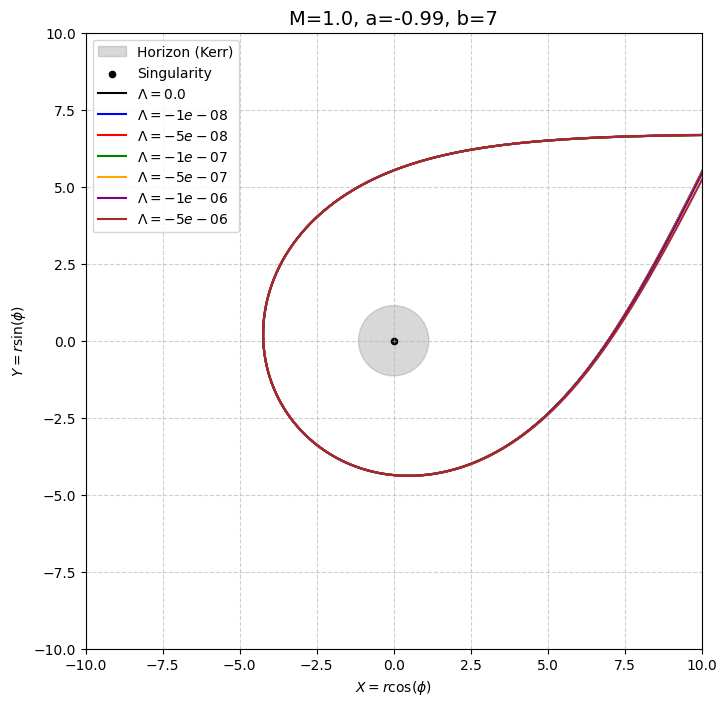

In [7]:
fig, ax = plt.subplots(figsize=(8,8))
colors = ['black', 'blue', 'red', 'green', 'orange', 'purple', 'brown']

# Gambar Event Horizon
eventhorizon = plt.Circle((0,0), rh, color='gray', alpha=0.3, label="Horizon (Kerr)")
ax.add_artist(eventhorizon)
ax.scatter(0, 0, s=20, c='k', label='Singularity')

# Plot garis dari data trajektori yang sudah dihitung
for i, (lmd, X_vals, Y_vals) in enumerate(trajectories):
    label_txt = f'$\\Lambda = {lmd}$'
    # Menggunakan modulo jika jumlah lambda melebihi jumlah warna
    ax.plot(X_vals, Y_vals, color=colors[i % len(colors)], label=label_txt, linewidth=1.5)

# Formatting Plot
ax.set_title(f"M={M}, a={a}, b={b}", fontsize=14)
ax.set_xlabel(r'$X = r \cos(\phi)$')
ax.set_ylabel(r'$Y = r \sin(\phi)$')
ax.set_aspect('equal')

limit = 10
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

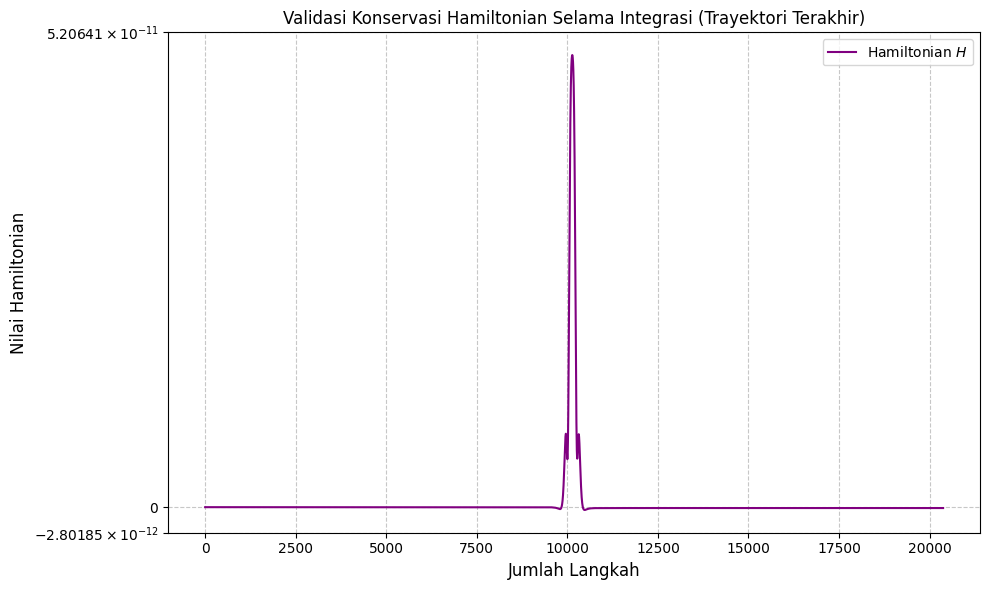

In [8]:
# Validasi Konservasi Hamiltonian
steps_arr = np.arange(len(hamiltonian_values))
hamiltonian_arr = np.array(hamiltonian_values)

# Hitung fluktuasi (max - min)
H_max = np.max(hamiltonian_arr)
H_min = np.min(hamiltonian_arr)
fluctuation = H_max - H_min

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(steps_arr, hamiltonian_arr, color='purple', label='Hamiltonian $H$')

# Log scale pada sumbu Y jika fluktuasinya sangat kecil
if fluctuation > 0 and fluctuation < 1e-3:
    # Memusatkan log-scale di sekitar nilai rata-rata, atau gunakan symlog untuk variasi kecil di sekitar angka negatif/positif
    ax.set_yscale('symlog', linthresh=0.001)

ax.set_title("Validasi Konservasi Hamiltonian Selama Integrasi (Trayektori Terakhir)")
ax.set_xlabel("Jumlah Langkah", fontsize=12)
ax.set_ylabel("Nilai Hamiltonian", fontsize=12)

ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

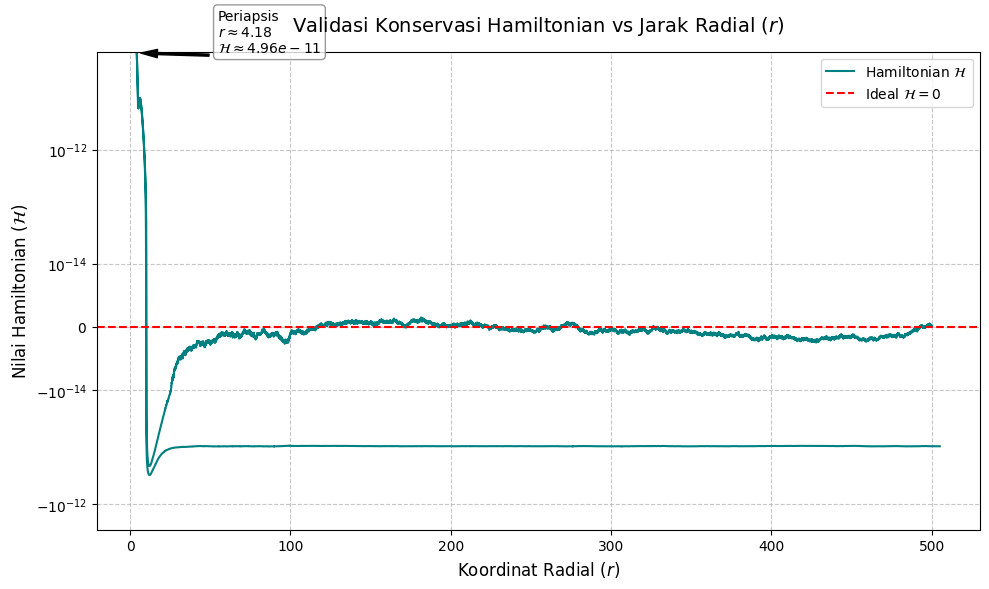

In [9]:
# Mengambil data r dan H dari hasil integrasi (trajektori terakhir)
# X_vals dan Y_vals serta hamiltonian_values sudah ada di memori dari cell sebelumnya
r_vals = np.sqrt(np.array(X_vals)**2 + np.array(Y_vals)**2)
H_vals = np.array(hamiltonian_values)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot H_vals vs r_vals
ax.plot(r_vals, H_vals, color='teal', linewidth=1.5, label=r'Hamiltonian $\mathcal{H}$')

# Garis horizontal putus-putus pada y=0 sebagai referensi nilai ideal
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label=r'Ideal $\mathcal{H} = 0$')

# Skala logaritmik symlog untuk sumbu Y agar fluktuasi orde kecil (1e-11 s/d 1e-14) terlihat
# Menggunakan symlog karena nilai H bisa sedikit berfluktuasi ke nilai negatif dan positif di sekitar 0
ax.set_yscale('symlog', linthresh=1e-14)

# Mencari titik periapsis (r terkecil)
min_r_idx = np.argmin(r_vals)
min_r = r_vals[min_r_idx]
H_at_min_r = H_vals[min_r_idx]

# Memberikan anotasi otomatis pada r terkecil (periapsis)
ax.annotate(f'Periapsis\n$r \\approx {min_r:.2f}$\n$\mathcal{{H}} \\approx {H_at_min_r:.2e}$',
            xy=(min_r, H_at_min_r),
            xytext=(min_r + max(r_vals)*0.1, H_at_min_r + 1e-12),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Pengaturan Judul dan Label Sumbu
ax.set_title("Validasi Konservasi Hamiltonian vs Jarak Radial ($r$)", fontsize=14, pad=15)
ax.set_xlabel("Koordinat Radial ($r$)", fontsize=12)
ax.set_ylabel(r"Nilai Hamiltonian ($\mathcal{H}$)", fontsize=12)

# Grid dan Legend
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()